In this notebook, we'll implement a minimal example of a 1D Gaussian process and apply this approach to regression.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [42]:
# The kernel, which describes the correlation between y(x1) and y(x2) as a function of |x1-x2|:
# sig is hyperparameter that controls how quickly the correlation decays as x1 and x2 get further apart
def k(x1, x2, sig=0.3):
    return np.exp(-(x1-x2)**2/(2*sig)**2)

**Exercise**: For $N=100$ evenly spaced x values over $(0,1)$, let $\vec{y}$ be a vector of the corresponding $y$ values such that $p(\vec{y}) = \mathcal{N}(\vec{y} | 0, \mathbf{K})$. Use the kernel function defined above to create the covariance matrix $\mathbf{K}$. Use `np.random.multivariate_normal()` to draw and plot a few samples from this distribution.

In [43]:
np.random.multivariate_normal?

Docstring:
multivariate_normal(mean, cov, size=None, check_valid='warn', tol=1e-8)

Draw random samples from a multivariate normal distribution.

The multivariate normal, multinormal or Gaussian distribution is a
generalization of the one-dimensional normal distribution to higher
dimensions.  Such a distribution is specified by its mean and
covariance matrix.  These parameters are analogous to the mean
(average or "center") and variance (standard deviation, or "width,"
squared) of the one-dimensional normal distribution.

.. note::
    New code should use the
    `~numpy.random.Generator.multivariate_normal`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
mean : 1-D array_like, of length N
    Mean of the N-dimensional distribution.
cov : 2-D array_like, of shape (N, N)
    Covariance matrix of the distribution. It must be symmetric and
    positive-semidefinite for proper sampling.
size : int or tuple of 

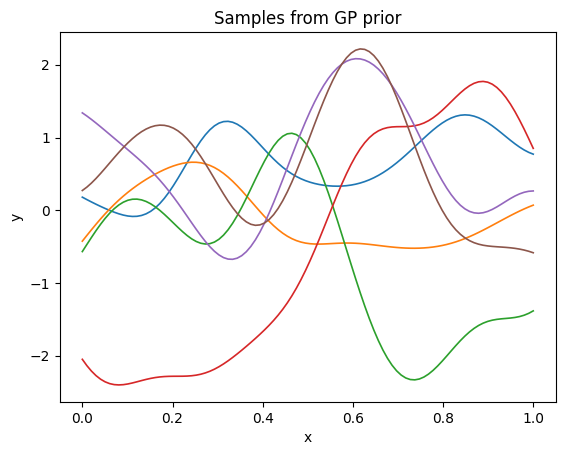

In [27]:
## Solution ##
N =100
# Create the covariance matrix:
K = np.zeros((N, N))
x = np.linspace(0, 1, N)
for i in range(N):
    for j in range(N):
        K[i, j] = k(x[i], x[j])
# Draw some samples (i.e. functions y(x)) from the distribution over y:
n_samples = 6
y = np.random.multivariate_normal(mean=np.zeros(N), cov=K, size=n_samples)
# Plot the results:
for s in y:   
    plt.plot(x, s, lw=1.2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from GP prior')
plt.show()

In [28]:
y.shape

(6, 100)

### Equations for What We Have Done So Far

We define a 1D kernel (squared-exponential / RBF):
$$
k(x_i, x_j) = \exp\left(-\frac{(x_i-x_j)^2}{(2\sigma)^2}\right), \qquad \sigma = 0.1.
$$

Using evenly spaced inputs $x_1,\dots,x_N$ with $N=100$, we build the covariance matrix
$$
\mathbf{K} \in \mathbb{R}^{N\times N}, \qquad K_{ij} = k(x_i, x_j).
$$

The latent function values are modeled as a Gaussian process prior, which in finite form is
$$
\mathbf{y} = [y(x_1),\dots,y(x_N)]^T \sim \mathcal{N}(\mathbf{0}, \mathbf{K}).
$$

So the joint density is
$$
p(\mathbf{y}) = \frac{1}{(2\pi)^{N/2}|\mathbf{K}|^{1/2}}
\exp\left(-\frac{1}{2}\mathbf{y}^T\mathbf{K}^{-1}\mathbf{y}\right).
$$

In code, `np.random.multivariate_normal(mean=np.zeros(N), cov=K, size=5)` draws 5 samples
$$
\mathbf{y}^{(1)},\dots,\mathbf{y}^{(5)} \sim \mathcal{N}(\mathbf{0},\mathbf{K}),
$$
which correspond to 5 random functions plotted versus $x$.

# Gaussian process regression


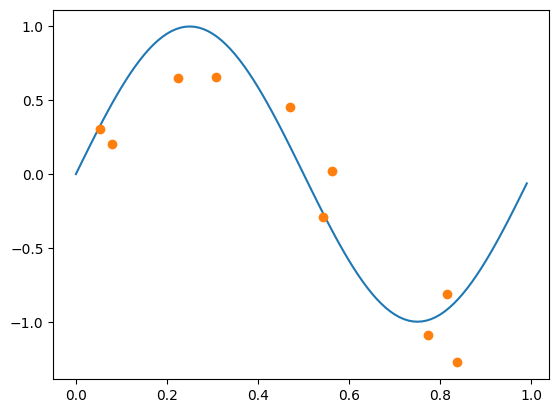

In [37]:
# Make some fake data:
noise = 0.05  # aka beta inverse
n = 10
x = np.random.rand(n)
y = np.sin(2*np.pi*x) + noise**0.5*np.random.randn(n)

n_array = 100
x_array = np.arange(0, 1, 1/n_array)
y_true = np.sin(2*np.pi*x_array)

# Plot the data together with the function that was used to generate it:
plt.plot(x_array, y_true)
plt.plot(x, y, 'o')

**Exercise**: Using the `n` data points defined above, create the covariance matrix $\mathbf{C}_N$. Use this to compute $m(\vec{x}_{N+1})$ and $\sigma^2(\vec{x}_{N+1})$ for the distribution of expected $t$ values corresponding to a new data point, i.e. $p(t_{N+1} | \vec{t}) = \mathcal{N}(t_{N+1} | m(\vec{x}_{N+1}), \sigma^2(\vec{x}_{N+1}))$. Compute these quantities for each data point in `x_array` defined above, and save the results in 1D arrays `m` and `s2`.

### PRML Definitions for GP Predictive Mean and Variance

For training inputs $\mathbf{x}=(x_1,\dots,x_N)^T$ and targets $\mathbf{t}$, define
$$
\mathbf{C}_N = \mathbf{K}_N + \beta^{-1}\mathbf{I},
$$
where
$$
(\mathbf{K}_N)_{ij}=k(x_i,x_j),\qquad \beta^{-1}=\text{noise variance}.
$$

For a new input $x_{N+1}$, define the kernel vector
$$
\mathbf{k} = \begin{bmatrix}k(x_1,x_{N+1}) & \cdots & k(x_N,x_{N+1})\end{bmatrix}^T,
$$
and self-kernel
$$
c = k(x_{N+1},x_{N+1}).
$$

Then (PRML) the predictive distribution is
$$
p(t_{N+1}\mid \mathbf{t}) = \mathcal{N}\big(t_{N+1}\mid m(x_{N+1}),\sigma^2(x_{N+1})\big),
$$
with
$$
m(x_{N+1}) = \mathbf{k}^T\mathbf{C}_N^{-1}\mathbf{t},
$$
$$
\sigma^2(x_{N+1}) = c - \mathbf{k}^T\mathbf{C}_N^{-1}\mathbf{k} + \beta^{-1}.
$$

Equivalent vector notation:
$$
m(\vec{x}_{N+1}) = \mathbf{k}^T\mathbf{C}_N^{-1}\mathbf{t},
\qquad
\sigma^2(\vec{x}_{N+1}) = k(\vec{x}_{N+1},\vec{x}_{N+1}) - \mathbf{k}^T\mathbf{C}_N^{-1}\mathbf{k} + \beta^{-1}.
$$

In [ ]:
## Solution ##
x_array = np.linspace(0,1,100) # grid of test points
C_n = np.zeros((n,n))
for i, xi in enumerate(x):
    for j, xj in enumerate(x):
        C_n[i,j] = k(xi,xj) + noise * (i==j)
CN_inv = np.linalg.inv(C_n)

# Create the covariance matrix and take its inverse:
m, s2 = np.zeros(n_array),np.zeros(n_array)
for i, xx in enumerate(x_array):
    m[i] = k(xx,x)@ CN_inv @ y
    s2[i]=noise+k(xx,xx)-k(xx,x)@CN_inv @k(xx,x)
# The means and variances of predicted t values for each x in x_array:


**Exercise**: Using the quantities just computed, plot the curve that gives the model predictions. The uncertainty of the prediction can be shown as a shaded region using `plt.fill_between()`.

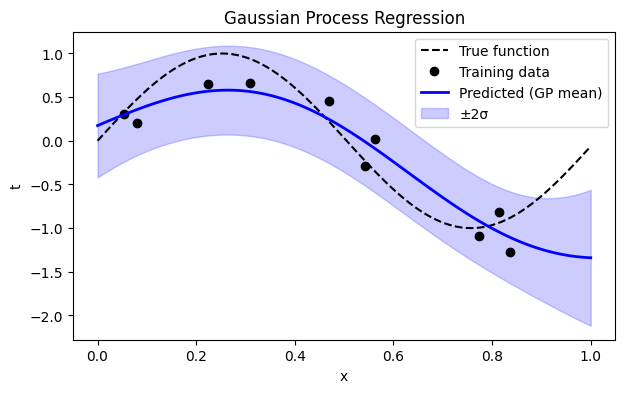

In [48]:
## Solution ##

# Plot the data together with the GP fit:
plt.figure(figsize=(7, 4))
plt.plot(x_array, y_true, 'k--', lw=1.5, label='True function')
plt.plot(x, y, 'ko', ms=6, label='Training data')
plt.plot(x_array, m, 'b', lw=2, label='Predicted (GP mean)')

std = np.sqrt(s2)
plt.fill_between(x_array, m - 2*std, m + 2*std, color='b', alpha=0.2, label='±2σ')

plt.xlabel('x')
plt.ylabel('t')
plt.title('Gaussian Process Regression')
plt.legend()
plt.show()